# Inference the results of the thrmodynamic experiment

In [4]:
import sys
import gc
sys.path.append('../')

In [5]:
from model.data_loader import fetch_dataloader,fetch_inference_loader
from model.data_loader import params as data_params
from model.model_cfg import CFG
# from model.net import ProteinEnergyNet
from model.hydro_net import PEM
from model.net import params as model_params
from train_utils import *
import torch
import torch.nn.functional as F
from torch import optim
from torch.optim import lr_scheduler
from tqdm import tqdm
import gc
import time
import sys
import pandas as pd
import wandb
import constants as C

In [6]:
os.chdir("../")
os.getcwd()

'/casp15/Shahar/DeepPEF'

# set validation function

In [7]:
def get_exmample(data_loder_item, device):
    # get the inputs; data is a list of [inputs, labels]   
    id, crd_backbone, mask, seq_one_hot, seq,ang_backbone, ang, proT5_emb, proT5_mut,seq_mut = data_loder_item

    Xjf = crd_backbone.to(device) # wilde type structure folded
    Xkf = torch.clone(Xjf).to(device) # mutant structure folded
    Xju = torch.clone(Xjf).to(device) # wilde type structure unfolded
    Xku = torch.clone(Xjf).to(device) # mutant structure unfolded

    mask = mask.to(device)
    mask_decoy = torch.clone(mask).to(device)

    seq_one_hot = seq_one_hot.to(device) # [batch_size,seq_len,20]
    seq_one_hot_mut = get_one_hot(seq_mut[0]).to(device) # [batch_size,seq_len,20]

    emb = seq_one_hot.to(device)
    emb_decoy = seq_one_hot_mut.to(device)
    # move proT5_emb to device
    proT5_mut, proT5_emb = proT5_mut.to(device), proT5_emb.to(device)
    # squeeze the data
    Xjf, Xkf, Xju, Xku = Xjf.squeeze(), Xkf.squeeze(), Xju.squeeze(), Xku.squeeze()
    emb_decoy, emb = emb_decoy.squeeze(), emb.squeeze()
    mask_decoy, mask= mask_decoy.squeeze(), mask.squeeze()
    proT5_mut, proT5_emb = proT5_mut.squeeze(), proT5_emb.squeeze()
    # get folded graph  
    Xjf,Xkf = get_graph(Xjf, emb, proT5_emb, mask), get_graph(Xkf, emb, proT5_mut, mask)
    # get unfolded graph
    Xju,Xku = get_unfolded_graph(Xju, emb, proT5_emb, mask), get_unfolded_graph(Xku, emb, proT5_mut, mask)

    return Xjf,Xkf,Xju,Xku

In [8]:
model = PEM(layers=3,gaussian_coef=CFG.gaussian_coef).to(CFG.device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {total_params}")

Number of parameters: 393085


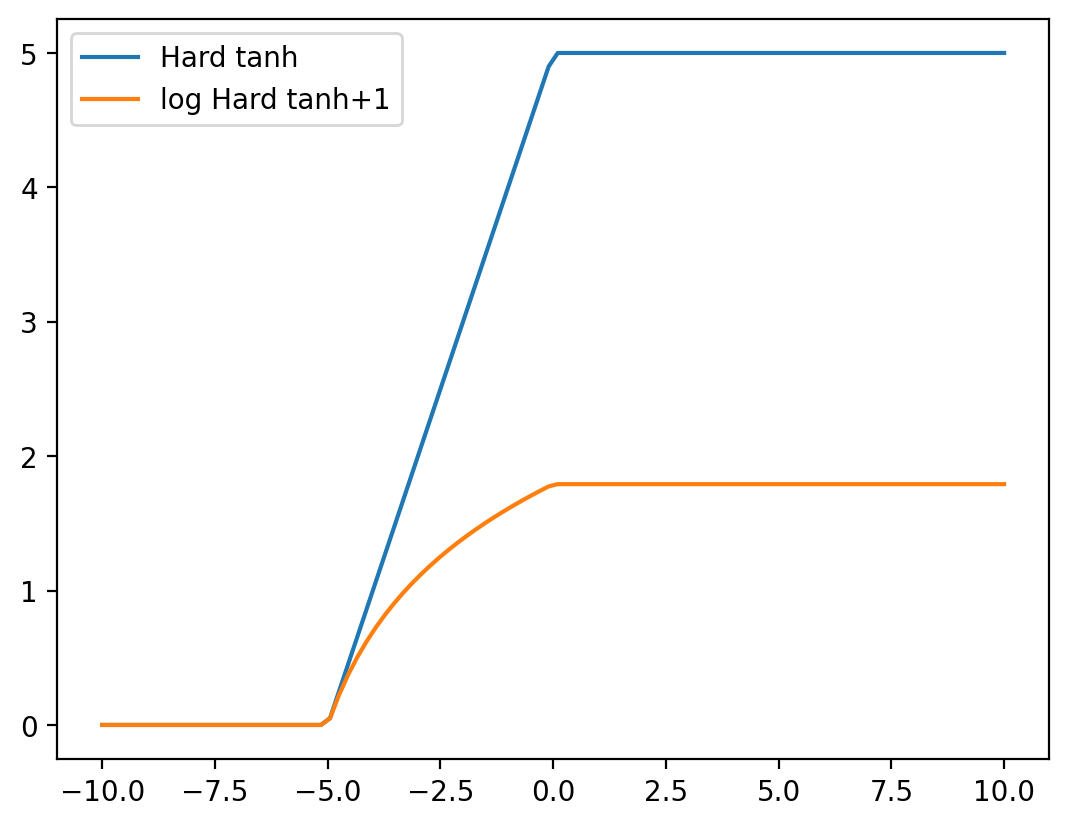

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import torch
# retina display
%config InlineBackend.figure_format = 'retina'

# Implement hard tanh
h_tanh = torch.nn.Hardtanh(0, 5)
x = torch.linspace(-10, 10, 100)
offset = 5
plt.plot(x, h_tanh(x + offset), label='Hard tanh')
plt.plot(x, torch.log(h_tanh(x + offset)+1), label='log Hard tanh+1')
plt.legend()

In [10]:
model = PEM(layers=CFG.num_layers,gaussian_coef=CFG.gaussian_coef).to(CFG.device)
model.name = "PEM-thermodynamic cycle"
optimizer = optim.Adam(model.parameters(), lr=CFG.lr, weight_decay=CFG.wd)

In [11]:
model,optimizer,epoch,loss,valid_loss = load_checkpoint("./res/trianed_models_th_mix_100_16bit/best_model.pt",model,optimizer,device=CFG.device)

Loaded model from ./res/trianed_models_th_mix_100_16bit/best_model.pt


1A0N example

In [12]:
def add_cb(crd_coords):
        """
        Add the Cbeta atom to the coordinates
        Args:
            crd_coords (tensor): tensor of shape [n_residues,3,3]

        Returns:
            crd_coords: tensor shape [n_residues,4,3]
        """
        # Get the coordinates of the backbone atoms
        N, CA, C = crd_coords[:, 0], crd_coords[:, 1], crd_coords[:, 2]
        # CB = CA + c1*(N-CA) + c2*(C-CA) + c3* (N-CA)x(C-CA)
        CAmN = N - CA
        # CAmN = CAmN / torch.sqrt(CAmN ** 2).sum(dim=2, keepdim=True)
        CAmC = C - CA
        # CAmC = CAmC / torch.sqrt(CAmC ** 2).sum(dim=2, keepdim=True)
        ANxAC = torch.cross(CAmN, CAmC, dim=1)

        A = torch.cat((CAmN.reshape(-1, 1), CAmC.reshape(-1, 1), ANxAC.reshape(-1, 1)), dim=1)
        c = torch.tensor([0.5507, 0.5354, -0.5691]) / 100  # torch.tensor([1.1930, 1.2106, -2.7906]) #
        b = (A @ c).reshape(-1,3)
        CB = CA - b
      
        # Add Cbeta coordinates to existing coordinates array
        crd_coords = torch.cat((crd_coords, CB.unsqueeze(1)), dim=1)
        return crd_coords
    

In [40]:
item_path = './data/casp12_data_100/train/1A0N_2_B'
item_path = './data/casp12_data_100/train/1WR4_1_A'
item_path = './data/casp12_data_100/train/2B89_1_A'
# load data
id = torch.load(item_path + '/id.pt')
crd_backbone = torch.tensor(torch.load(item_path + '/crd_backbone.pt'),dtype=torch.get_default_dtype()) #backbone coordinates N,Calpha,C
mask = torch.load(item_path + '/mask.pt')
# change to 1,0 mask
mask = torch.tensor(np.where(np.array(list(mask))=='+',1,0))
seq_one_hot = torch.load(item_path + '/seq_one_hot.pt')
seq = torch.load(item_path + '/seq.pt')
proT5_emb = torch.load(item_path + '/proT5_emb.pt')
# proT5_emb = torch.zeros((len(seq),1024)) # for testing
ang = torch.tensor(torch.load(item_path + '/ang.pt'))
ang_backbone = torch.clone(ang)[:,:3] #angles for the backbone phi, psi, omega
# Add Cbeta atom to the coordinates
crd_backbone = add_cb(crd_backbone)
crd_backbone = crd_backbone * C.NANO_TO_ANGSTROM # Convert to angstrom

# ProT5 embedding for protein mutation
proT5_mut = torch.load(item_path + '/proT5_emb_mut.pt')
seq_mut =  torch.load(item_path + '/seq_mut.pt')
# proT5_mut = torch.zeros((len(seq),1024)) # for testing
# seq_mut = seq # for testing
id, crd_backbone, mask, seq_one_hot, seq,ang_backbone, ang, proT5_emb, proT5_mut,seq_mut = [id], crd_backbone.unsqueeze(0), mask.unsqueeze(0), seq_one_hot.unsqueeze(0), [seq],ang_backbone.unsqueeze(0), ang.unsqueeze(0), proT5_emb.unsqueeze(0), proT5_mut.unsqueeze(0),[seq_mut]

In [41]:
print(mask)

tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])


In [42]:
# evaluate model 
model.eval()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [43]:
# wild type and mutant type
Xjf = crd_backbone.to(device) # wilde type structure folded
Xkf = torch.clone(Xjf).to(device) # mutant structure folded
Xju = torch.clone(Xjf).to(device) # wilde type structure unfolded
Xku = torch.clone(Xjf).to(device) # mutant structure unfolded

# native structure and decoy structure
Xd = torch.clone(Xjf).to(device)
print(Xjf.shape,Xkf.shape,Xju.shape,Xku.shape,Xd.shape)
seq_one_hot = seq_one_hot.to(device) # [batch_size,20,seq_len]

# create decoy sequence
seq_decoy,mask_decoy, proT5_emb_decoy = mix_A_acid(seq_one_hot = seq_one_hot, emb=proT5_emb, mask = mask,val_type='train',device=device)

#emb = torch.cat((esm_embed,seq),dim=2)
emb = seq_one_hot.to(device)
emb_decoy = seq_decoy.to(device)
emb_mut = get_one_hot(seq_mut[0]).to(device)

# move proT5_emb to device
proT5_mut, proT5_emb_decoy, proT5_emb = proT5_mut.to(device), proT5_emb_decoy.to(device), proT5_emb.to(device)

# zero the parameter gradients
optimizer.zero_grad()
# squeeze the data
Xd, Xjf, Xkf, Xju, Xku = Xd.squeeze(), Xjf.squeeze(), Xkf.squeeze(), Xju.squeeze(), Xku.squeeze()
emb_decoy, emb, emb_mut = emb_decoy.squeeze(), emb.squeeze(), emb_mut.squeeze()
mask_decoy, mask= mask_decoy.squeeze(), mask.squeeze()
proT5_emb_decoy, proT5_emb, proT5_mut = proT5_emb_decoy.squeeze(), proT5_emb.squeeze(), proT5_mut.squeeze()

# get folded graph  
Xjf,Xkf = get_graph(Xjf, emb, proT5_emb, mask), get_graph(Xkf, emb_mut, proT5_mut, mask)
# get unfolded graph
Xju,Xku = get_unfolded_graph(Xju, emb, proT5_emb, mask), get_unfolded_graph(Xku, emb_mut, proT5_mut, mask)
# get decoy graph
Xd = get_graph(Xd, emb_decoy, proT5_emb_decoy, mask_decoy)
# create a batch of Xjf,Xkf,Xju,Xku,x_decoy
Xjf,Xkf,Xju,Xku,Xd = Xjf.unsqueeze(0),Xkf.unsqueeze(0),Xju.unsqueeze(0),Xku.unsqueeze(0),Xd.unsqueeze(0)    
Xjf.requires_grad = True
X = torch.cat((Xjf,Xkf,Xju,Xku,Xd),dim=0)
# calculate the energy for the folded unfolded and decoy structure
E = model(X)
Ejf, Ekf, Eju, Eku, Exd = E[0], E[1], E[2], E[3], E[4]
   

torch.Size([1, 58, 4, 3]) torch.Size([1, 58, 4, 3]) torch.Size([1, 58, 4, 3]) torch.Size([1, 58, 4, 3]) torch.Size([1, 58, 4, 3])


In [44]:
print(Ejf.item(), Ekf.item(), Eju.item(), Eku.item(), Exd.item())

1083.412841796875 1252.542236328125 773.1620483398438 888.4552612304688 3350.777587890625


In [45]:
E = model(X,f_type = 'A_inference')
# E = E.squeeze()
Ejf, Ekf, Eju, Eku, Exd = E[0], E[1], E[2], E[3], E[4]

(58, 5)


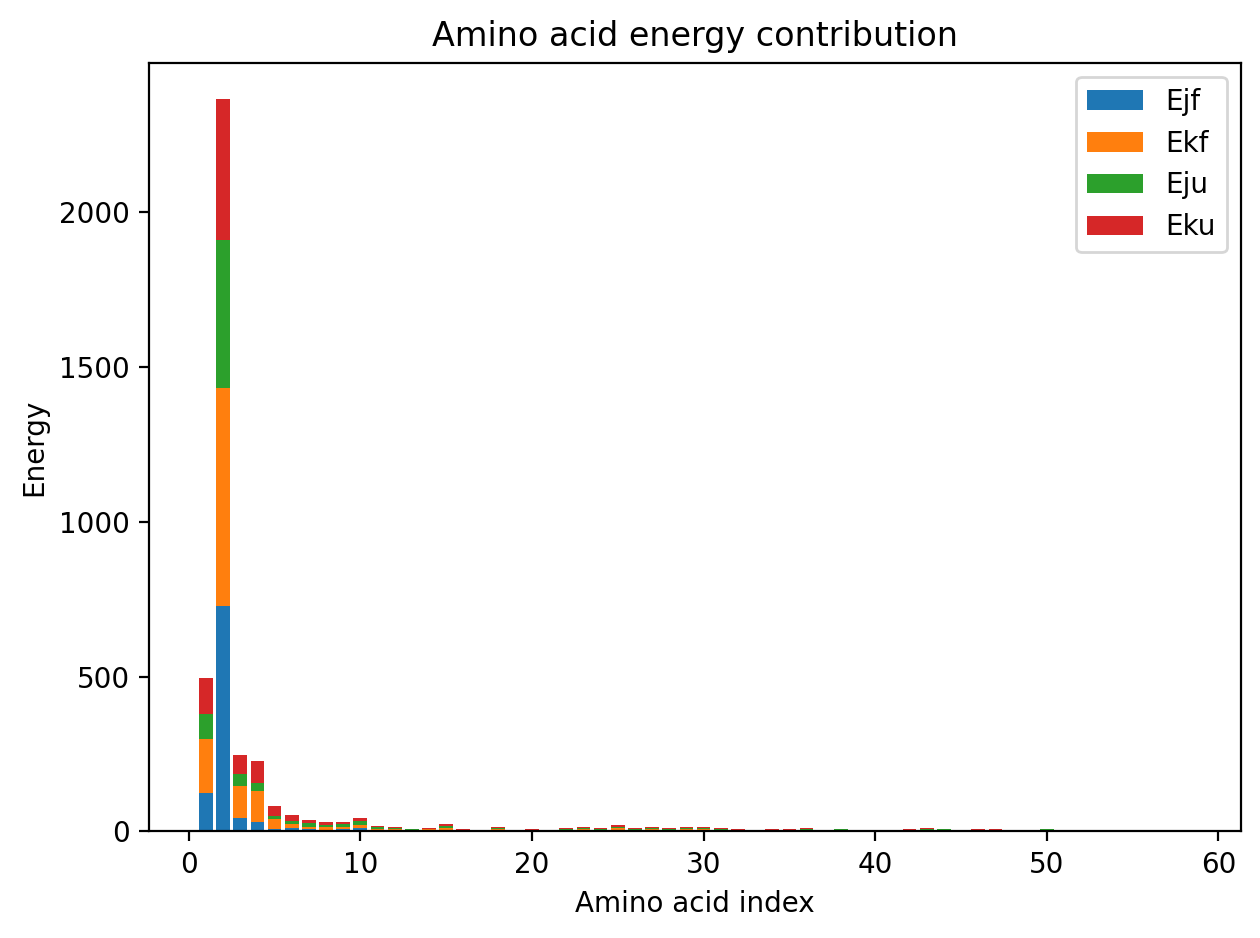

In [46]:
# Categories (x-axis labels)
nodes = Ejf.shape[0]
categories = np.arange(1, nodes+1)  # Assuming 69 data points


# Combine the data into a single array
data = np.hstack((Ejf.detach().cpu().numpy()**2, Ekf.detach().cpu().numpy()**2, Eju.detach().cpu().numpy()**2, Eku.detach().cpu().numpy()**2, Exd.detach().cpu().numpy()**2))
print(data.shape)
# Create the figure and axis objects
fig, ax = plt.subplots()

# Create the stacked bar chart
ax.bar(categories, data[:, 0], label='Ejf')
bottom = data[:, 0]
for i in range(1, data.shape[1]-1):
    ax.bar(categories, data[:, i], bottom=bottom, label=['Ejf', 'Ekf', 'Eju', 'Eku'][i])
    bottom += data[:, i]

# Set labels, title, and legend
plt.xlabel('Amino acid index')
plt.ylabel('Energy')
ax.set_title('Amino acid energy contribution')
ax.legend()

# Display the plot
plt.tight_layout()
plt.show()

In [20]:
grad = torch.autograd.grad(Ejf, Xjf, create_graph=True)[0]
torch.norm(grad**2)

RuntimeError: grad can be implicitly created only for scalar outputs